In [58]:
import os
import rasterio
import rioxarray as rxr
from scipy.stats import linregress
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import re
import glob


In [8]:
def find_date_directories(start_dir):
    """
    Finds all directories within start_dir whose names are exactly 6 digits.

    Args:
        start_dir (str): The path to the directory to start searching from.

    Returns:
        list: A list of full paths to the matching directories.
    """
    # Regex pattern to match exactly 6 digits
    # ^ asserts the start of the string, \\d{6} matches exactly six digits,
    # and $ asserts the end of the string.
    pattern = re.compile(r"^\d{8}$")
    matching_directories = []

    # os.walk traverses the directory tree recursively
    for root, dirs, files in os.walk(start_dir):
        # We only need to check the directory names (dirs) in the current root
        for dir_name in dirs:
            # Check if the directory name matches the 6-digit pattern
            if pattern.match(dir_name):
                # If it matches, construct the full path and add to the list
                full_path = os.path.join(root, dir_name)
                matching_directories.append(full_path)
    
    return matching_directories


In [14]:
def process_all_dates(parent_dir, task_number):
    """
    Processes multiple date-named directories to build a nested dictionary of model outputs.

    Args:
        parent_dir (str): The parent directory containing subdirectories named 'YYYYMMDD'.
        task_number (int): The task number (1 or 2).

    Returns:
        dict: A nested dictionary where keys are dates and values are dictionaries
              of model rasters for that date.
    """    
    date_dirs = find_date_directories(parent_dir)
    modeled_data = {}

    for dir in date_dirs:
            date_str = os.path.basename(dir)
            modeled_data[date_str] = {}
            
            raster = glob.glob(os.path.join(dir, 'modeled/SNODAS', "*basin_clip.tif"))
            if raster:
                modeled_data[date_str]['SNODAS-basin'] = raster[0] 
                
            raster = glob.glob(os.path.join(dir, 'modeled/SNODAS', '*MCS_clip.tif'))
            if raster:
                modeled_data[date_str]['SNODAS-MCS'] = raster[0] 
                
            if task_number == 1:
                output_dir = os.path.join(dir, "outputs/task1/rasters")
            else:
                output_dir = os.path.join(dir, "outputs/task2/rasters")
            
            #create lidar dictionary
            raster = glob.glob(os.path.join(output_dir, "*LiDAR_MCS_clip*.tif"))
            if raster:
                modeled_data[date_str]['lidar'] = raster[0]            
            
            #create dcitionary of outputs clipped to basin
            models_basin = {}
            raster_search_pattern = os.path.join(output_dir, "*_basin_clip.tif")
            for raster_path in glob.glob(raster_search_pattern):
                file_name = os.path.basename(raster_path)
                model_name = file_name.replace("_basin_clip.tif", "").replace("_", "-")
                models_basin[model_name] = raster_path  
             
            if models_basin:
                modeled_data[date_str]['basin_clip'] = models_basin  
            
            #create dictionary of outputs clipped to lidar domain    
            models_lidar = {}
            raster_search_pattern = os.path.join(output_dir, "*_MCS_clip.tif")
            for raster_path in glob.glob(raster_search_pattern):
                file_name = os.path.basename(raster_path)
                model_name = file_name.replace("_MCS_clip.tif", "").replace("_", "-")
                models_lidar[model_name] = raster_path
    
            if models_lidar:
                modeled_data[date_str]['lidar_clip'] = models_lidar  
                
            #create dictionary of outputs clipped to lidar domain and resampled
            models_resample = {}
            raster_search_pattern = os.path.join(output_dir, "*lidar_resample.tif")
            for raster_path in glob.glob(raster_search_pattern):
                file_name = os.path.basename(raster_path)
                model_name = file_name.replace("_lidar_resample.tif", "").replace("_", "-")
                models_resample[model_name] = raster_path
    
            if models_resample:
                modeled_data[date_str]['resample'] = models_resample
                
            #create dictionary of outputs differenced from lidar data
            models_diff = {}
            raster_search_pattern = os.path.join(output_dir, "*_lidar_diff.tif")
            for raster_path in glob.glob(raster_search_pattern):
                file_name = os.path.basename(raster_path)
                model_name = file_name.replace("_lidar_diff.tif", "").replace("_", "-")
                models_diff[model_name] = raster_path
            if models_diff:
                modeled_data[date_str]['diff'] = models_diff
                
                
    return modeled_data


In [94]:
task1 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)

print(task2["basin_clip"])

KeyError: 'basin_clip'

In [17]:
for date in task1.keys():
    print(date)
    
print(task1['20230405'])

20230405
20240315
20240418
20250404
20250501
{'SNODAS-basin': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\modeled/SNODAS\\SNODAS_20230405_basin_clip.tif', 'SNODAS-MCS': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\modeled/SNODAS\\SNODAS_20230405_MCS_clip.tif', 'lidar': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\LiDAR_MCS_clip.tif', 'basin_clip': {'HMS-EB': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\HMS_EB_basin_clip.tif', 'HMS-TI': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\HMS_TI_basin_clip.tif', 'iSnobal': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\iSnobal_basin_clip.tif', 'SnowModel': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\SnowModel_basin_clip.tif'}, 'lidar_clip': {'HMS-EB': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\2023

In [82]:
date = '20230405'

lidar = task1[date]['lidar']
resample = task1[date]['resample']

lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
lidar = lidar.where(lidar < 5)

for name, model_data in resample.items():
        raster = rxr.open_rasterio(model_data, masked=True).squeeze()
# Flatten
        x = lidar.values.flatten()
        y = raster.values.flatten()
    
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]
        
        print(name)
        print(linregress(x_clean, y_clean))


HMS-Energy-Balance
LinregressResult(slope=0.18008760626189826, intercept=1.2326338847382226, rvalue=0.6201725732942579, pvalue=3.2605082335545683e-295, stderr=0.004321942129540416, intercept_stderr=0.011960765331481767)
HMS-Temperature-Index
LinregressResult(slope=0.2674564933560427, intercept=1.680371611548972, rvalue=0.6102608457606115, pvalue=2.2817255705014183e-283, stderr=0.006587288048096349, intercept_stderr=0.018230000345361687)
iSnobal
LinregressResult(slope=0.8824589632738516, intercept=0.08136186518493105, rvalue=0.8716070499041947, pvalue=0.0, stderr=0.00939782713524977, intercept_stderr=0.026011201202772605)
SnowModel
LinregressResult(slope=0.8527069295749012, intercept=-0.034005245121424554, rvalue=0.8104182983280676, pvalue=0.0, stderr=0.011799849276727939, intercept_stderr=0.03280965111677063)


In [ ]:
for key in task1.keys():
    print(key)

In [61]:
regressions = []

for key in task1.keys():
    lidar = task1[key]['lidar']
    resample_task1 = task1[key]['resample']
    resample_task2 = task2[key]['resample']
    
    resample = {"Task 1":resample_task1, "Task 2":resample_task2}

    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    
    for task, raster in resample.items():
        for name, model_data in raster.items():
                raster = rxr.open_rasterio(model_data, masked=True).squeeze()
        # Flatten
                x = lidar.values.flatten()
                y = raster.values.flatten()
            
                mask = ~np.isnan(x) & ~np.isnan(y)
                x_clean = x[mask]
                y_clean = y[mask]
                
                regression_result = linregress(x_clean, y_clean)
                
                row = {
                    "task": task,
                    "date": key,
                    "model": name,
                    "slope": regression_result.slope,
                    "intercept": regression_result.intercept,
                    "rvalue": regression_result.rvalue,
                    "pvalue": regression_result.pvalue,
                    "stderr": regression_result.stderr
                }
            
                regressions.append(row)
                
    df = pd.DataFrame(regressions)
    df['r-squared'] = df['rvalue']**2
    df.to_csv('regression_results.csv', index=False)
        

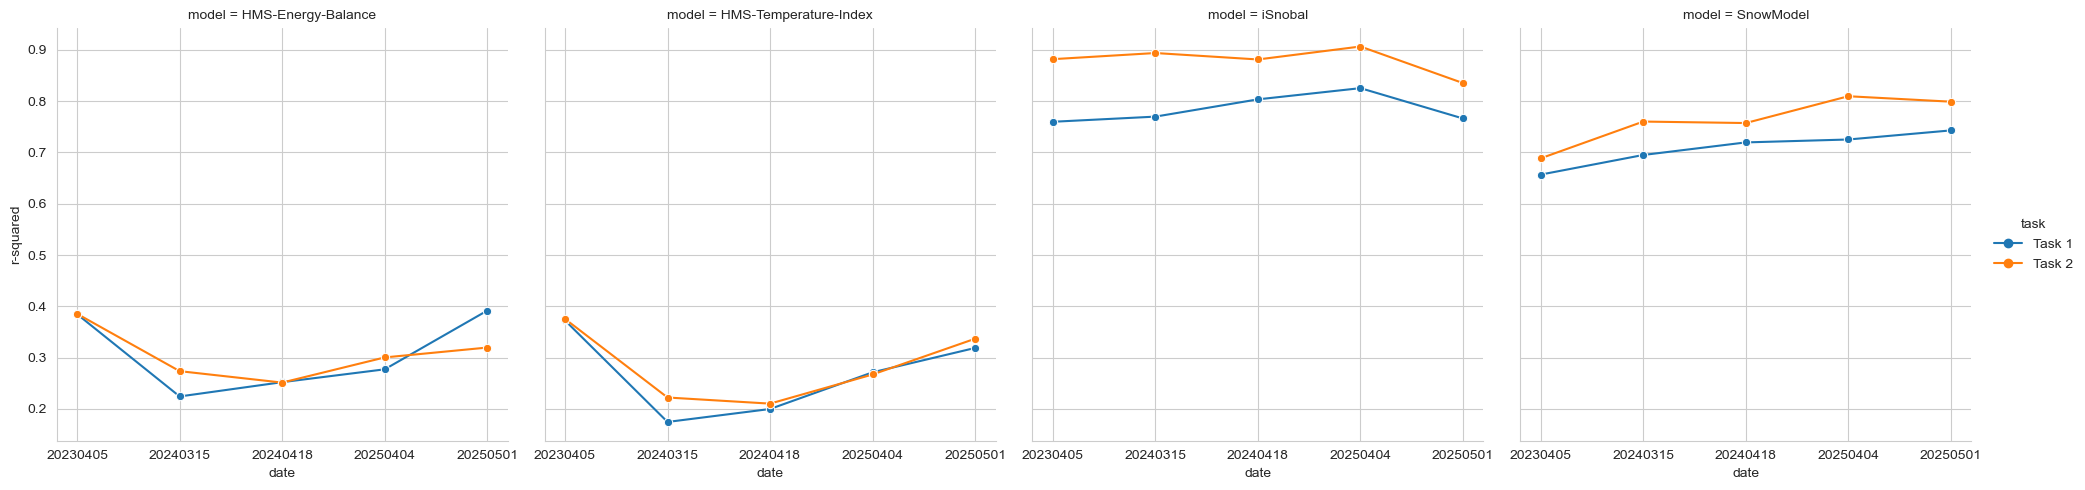

In [151]:
sns.relplot(
    data=df,
    x='date',
    y='r-squared',
    hue='task',
    col='model',
    kind='line',
    marker='o',
    col_wrap=4
)

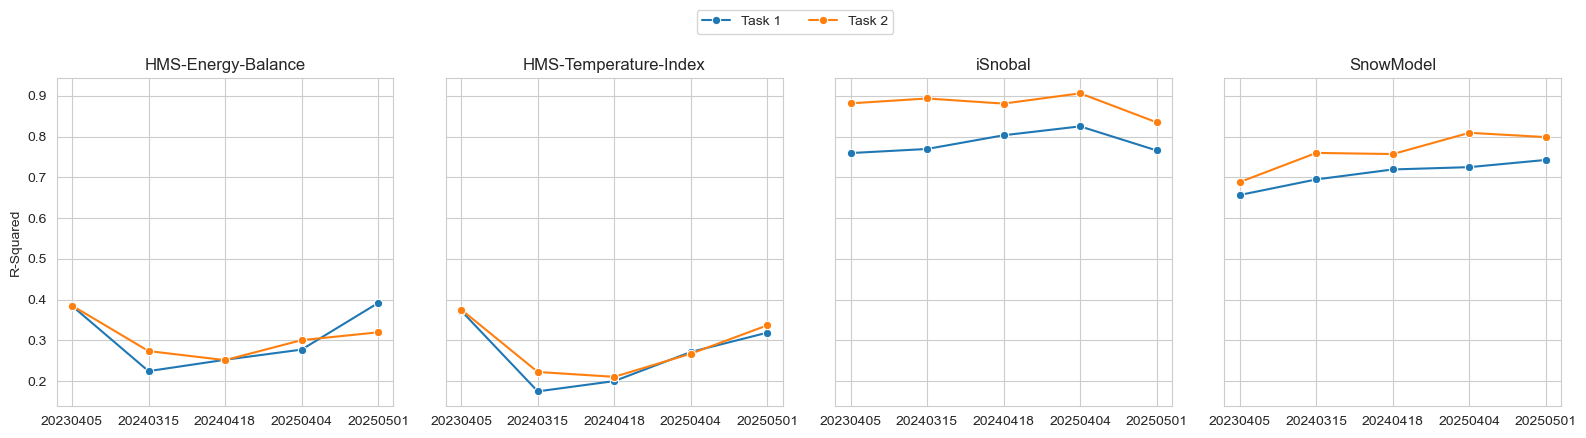

In [178]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(16, 4), sharey=True)

models = ['HMS-Energy-Balance', 'HMS-Temperature-Index', 'iSnobal', 'SnowModel']

for i, model in enumerate(models):
    sns.lineplot(
        data=df[df['model'] == model],
        x='date',
        y='r-squared',
        hue='task',
        marker='o',
        ax=axs[i],
          
    )
    axs[i].get_legend().remove()
    axs[i].set_title(model)
    axs[i].set_xlabel("")
    #axs[i].tick_params(labelrotation=45)
    axs[0].set_ylabel("R-Squared")
    
    handles, labels = axs[0].get_legend_handles_labels()

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3)

plt.tight_layout()
plt.show()

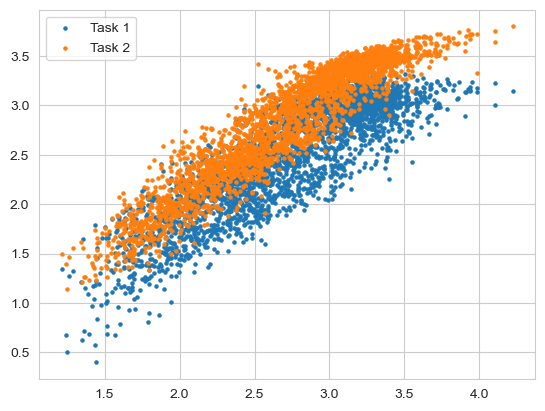

In [133]:
y1 = rxr.open_rasterio(resample_task1['iSnobal'], masked=True).squeeze()
y2 = rxr.open_rasterio(resample_task2['iSnobal'], masked=True).squeeze()
plt.scatter(lidar, y1, s=5, label='Task 1')
plt.scatter(lidar, y2, s=5, label='Task 2')
plt.legend(loc='upper left')

In [147]:
#date = '20230405'                                                                                      
# Data prep
def comparison_regressions(date):
    resample_task1 = task1[date]['resample']
    resample_task2 = task2[date]['resample']
    
    lidar = task1[date]['lidar']
    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    
    keys = list(resample_task1.keys())
    plt.figure(figsize=(4, 10))
    for idx in range(1, 5):
        plt.subplot(4, 1, idx)
        current_model1 = keys[idx-1]
        current_model2 = keys[idx-1]
        y1 = rxr.open_rasterio(resample_task1[current_model1], masked=True).squeeze()
        y2 = rxr.open_rasterio(resample_task2[current_model2], masked=True).squeeze()
        plt.scatter(lidar, y1, s=5, label='Task 1')
        plt.scatter(lidar, y2, s=5, label='Task 2')
        plt.legend(loc='upper left')
        plt.title(current_model1)
    plt.tight_layout()
    plt.show()
        

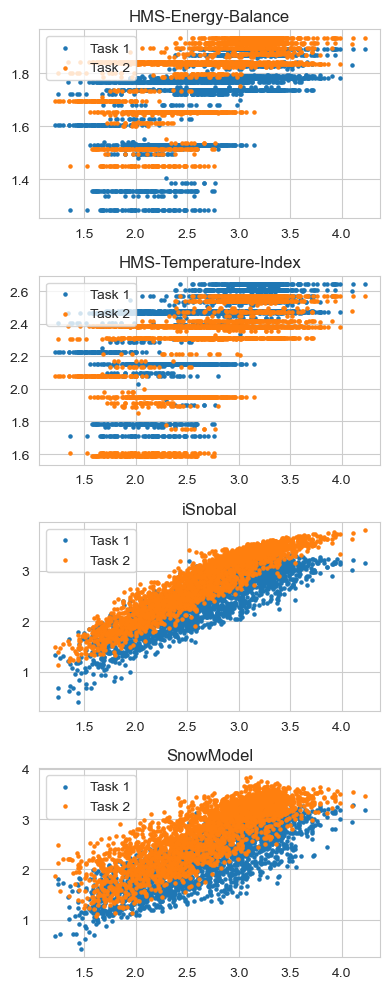

In [148]:
comparison_regressions('20230405')

In [181]:
# Assume 'lidar' is defined somewhere in your script as before

def create_regression_plot(YYYYMMDD, plot_title):
    """
    Generates and displays a 4-panel regression plot for snow depth models.

    Args:
        resample_data (dict): A dictionary where keys are model names and values 
                              are paths to the model's raster data.
        plot_date (str): The date string to be used as the main title for the figure.
    """
    sns.set_style('whitegrid')
    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(22, 5), sharey=True)
    fig.suptitle(plot_title, fontsize=18, fontweight='bold')
    
    # --- select data
    date = YYYYMMDD
    lidar = task1[date]['lidar']
    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    resample = task1[date]['resample']

    # --- Loop through each model to create a subplot ---
    for i, (name, model_data_path) in enumerate(resample.items()):
        raster = rxr.open_rasterio(model_data_path, masked=True).squeeze()
        
        # 1. Flatten and clean data
        x = lidar.values.flatten()
        y = raster.values.flatten()
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]

        ax = axs[i]
        
        # 2. Create the regression plot
        sns.regplot(x=x_clean, y=y_clean, ax=ax,
                    scatter_kws={'alpha': 0.8, 's': 10},
                    line_kws={'color': 'red'})
                    
        # 3. Calculate statistics
        slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
        r_squared = r_value**2
        
        # 4. Add titles and labels
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

        # 5. Add statistics text box
        stats_text = f'$R^2 = {r_squared:.3f}$\n$y = {slope:.2f}x + {intercept:.2f}$'
        ax.text(0.05, 0.95, stats_text, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6))

    # --- Final Figure-Level Adjustments ---
    axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)
    plt.tight_layout()
    
    # Display the final plot
    plt.show()



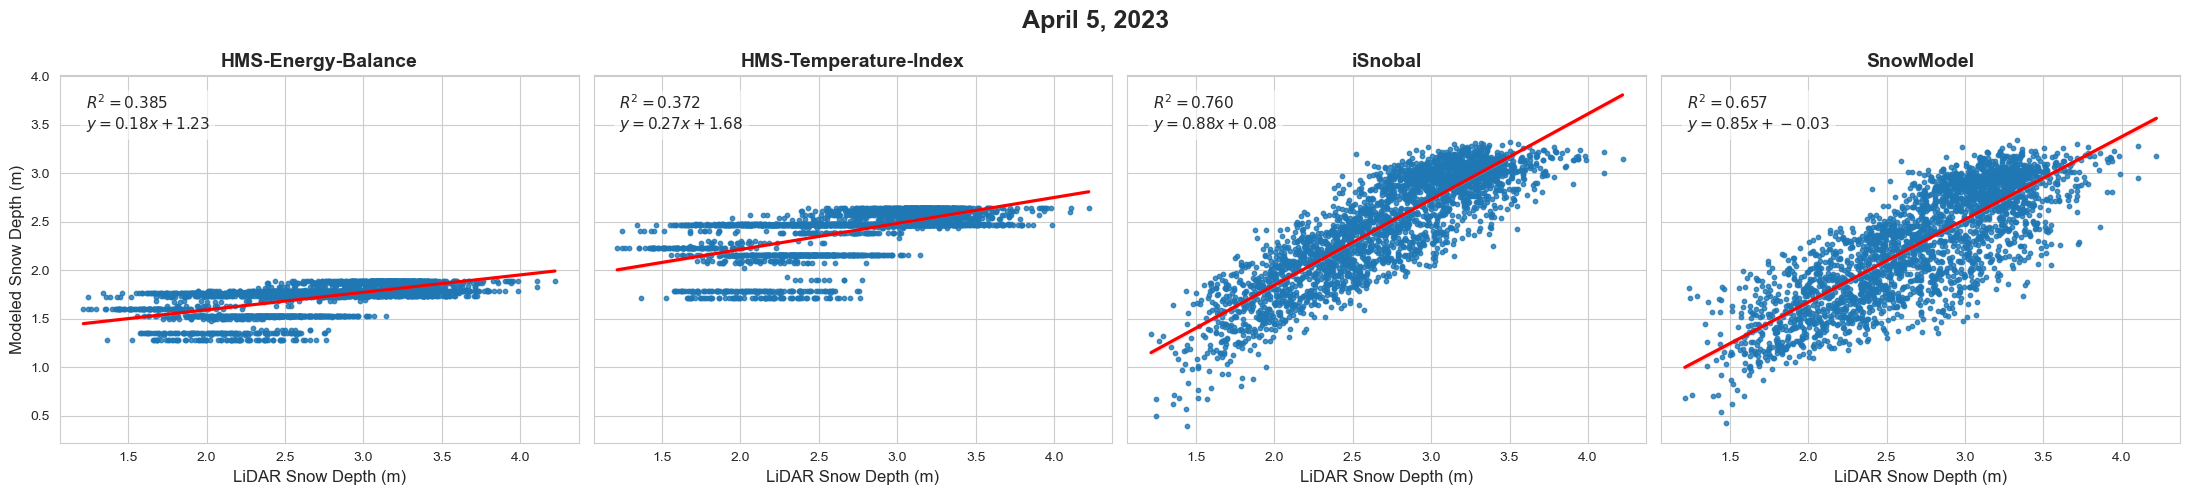

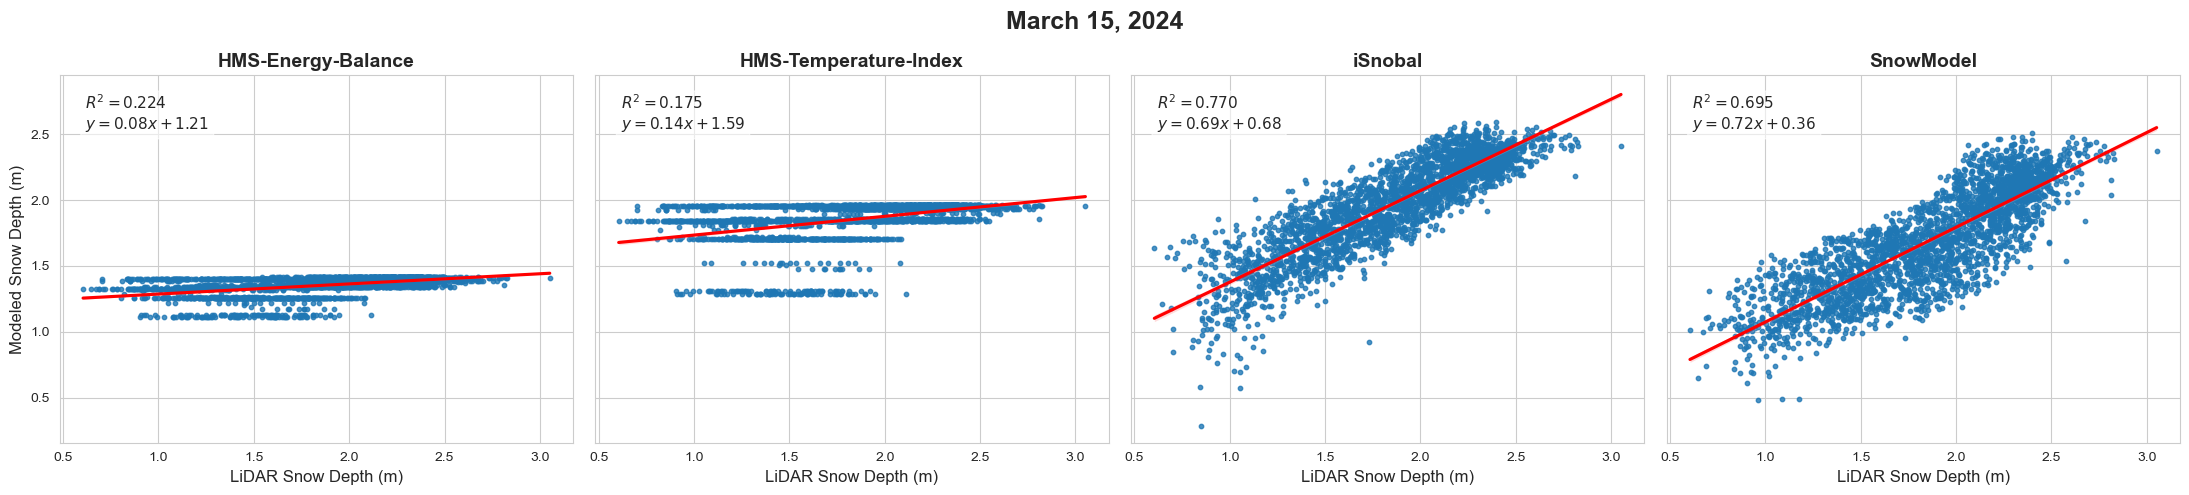

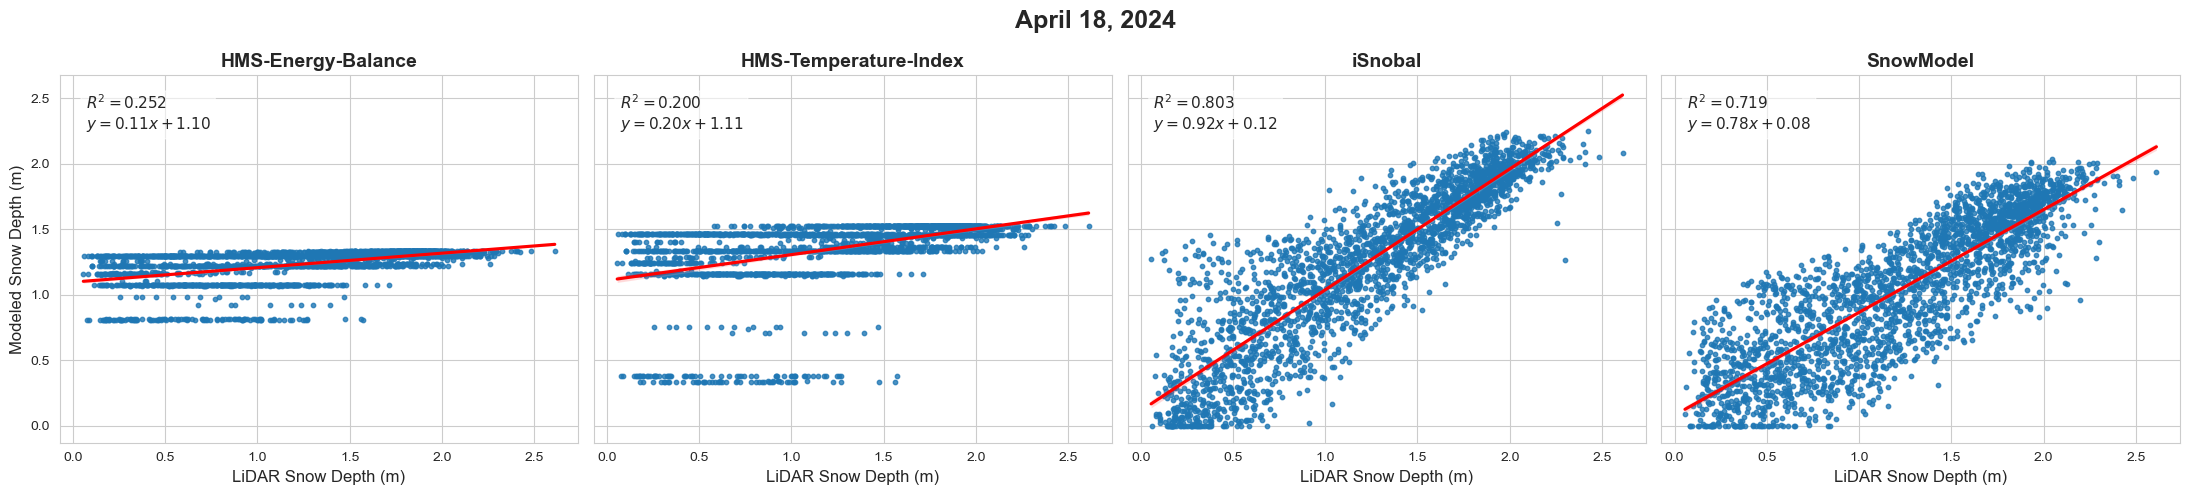

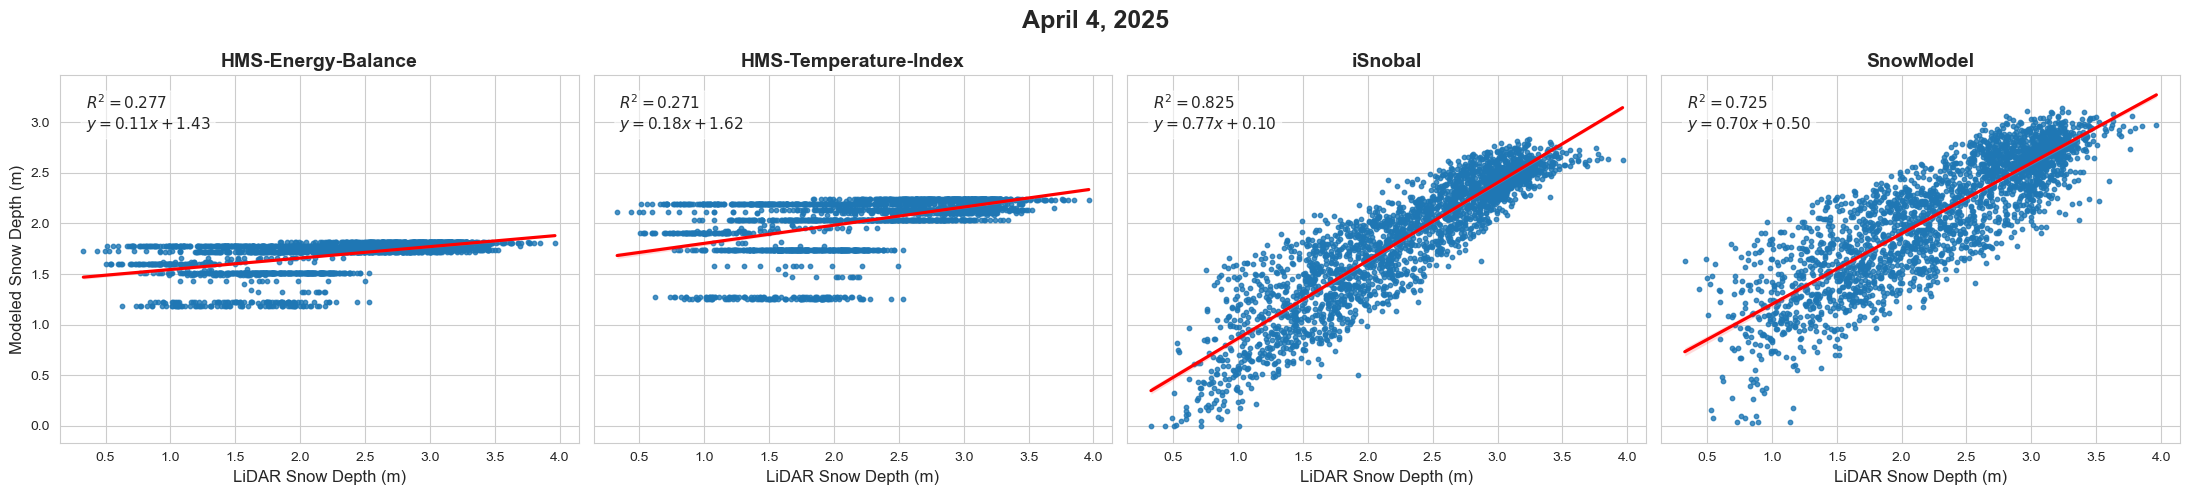

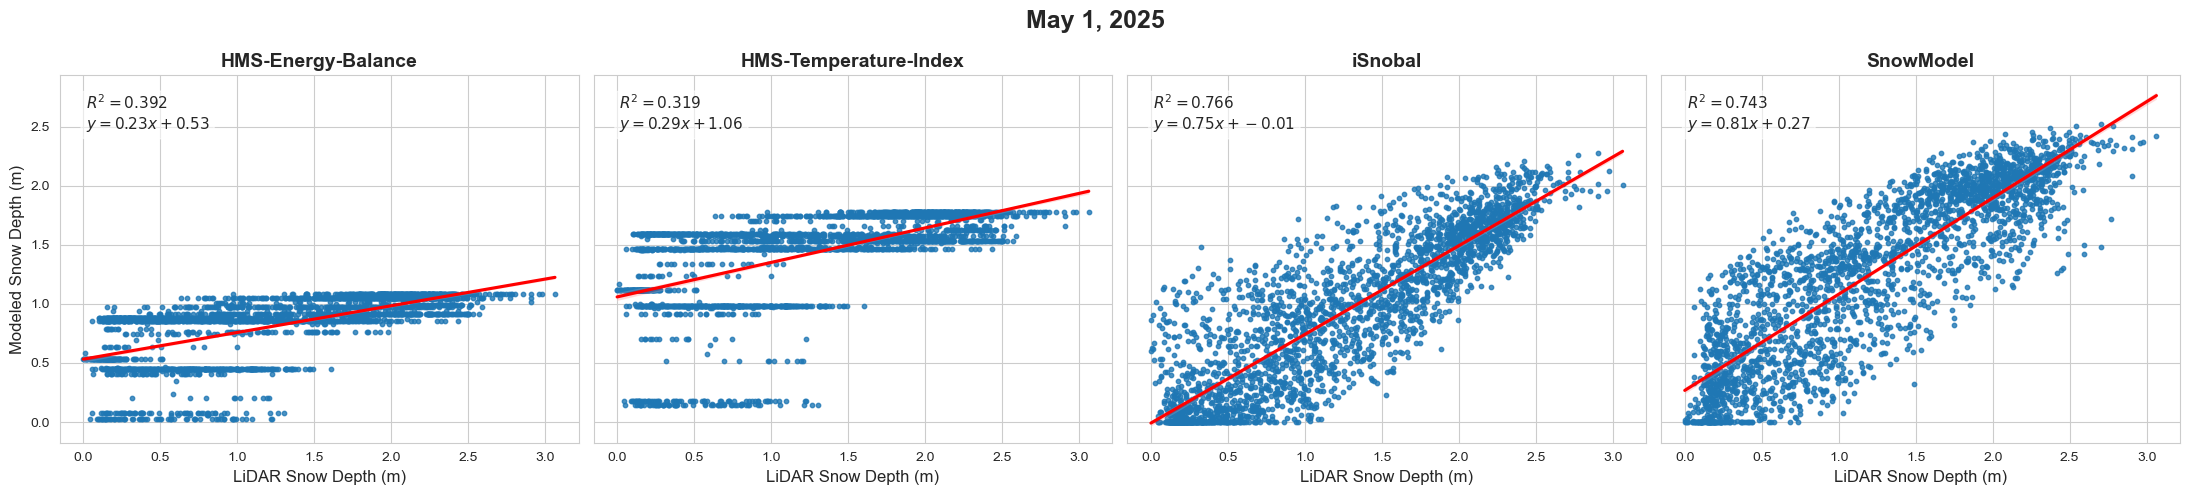

In [182]:
create_regression_plot('20230405', "April 5, 2023")
create_regression_plot('20240315', "March 15, 2024")
create_regression_plot('20240418', "April 18, 2024")
create_regression_plot('20250404', "April 4, 2025")
create_regression_plot('20250501', "May 1, 2025")



In [197]:
# Assume 'lidar' is defined somewhere in your script as before

def regression_plot_compare(YYYYMMDD, plot_title):

    sns.set_style('whitegrid')
    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(22, 5), sharey=True)
    fig.suptitle(plot_title, fontsize=18, fontweight='bold')
    
    # --- select data
    date = YYYYMMDD
    lidar = task1[date]['lidar']
    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    resample_task1 = task1[date]['resample']
    resample_task2 = task2[date]['resample']
    keys = list(resample_task1.keys())
    
    for idx in range(4):
        ax = axs[idx]
        model_name = keys[idx]
        y1 = rxr.open_rasterio(resample_task1[model_name], masked=True).squeeze()
        y2 = rxr.open_rasterio(resample_task2[model_name], masked=True).squeeze()
        
        x = lidar.values.flatten()
        y1_flat = y1.values.flatten()
        y2_flat = y2.values.flatten()

        sns.regplot(x=x, y=y1_flat, ax=axs[idx-1]) #scatter_kws={'alpha': 0.8, 's': 10})
        sns.regplot(x=x, y=y2_flat, ax=axs[idx-1]) #scatter_kws={'alpha': 0.8, 's': 10})
           
        # # 3. Calculate statistics
        # slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
        # r_squared = r_value**2
        
        # 4. Add titles and labels
        ax.set_title(model_name, fontsize=14, fontweight='bold')
        ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

        # # 5. Add statistics text box
        # stats_text = f'$R^2 = {r_squared:.3f}$\n$y = {slope:.2f}x + {intercept:.2f}$'
        # ax.text(0.05, 0.95, stats_text, 
        #         transform=ax.transAxes, 
        #         fontsize=11, 
        #         verticalalignment='top',
        #         bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6))

    # --- Final Figure-Level Adjustments ---
    axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)
    plt.tight_layout()
    
    # Display the final plot
    plt.show()



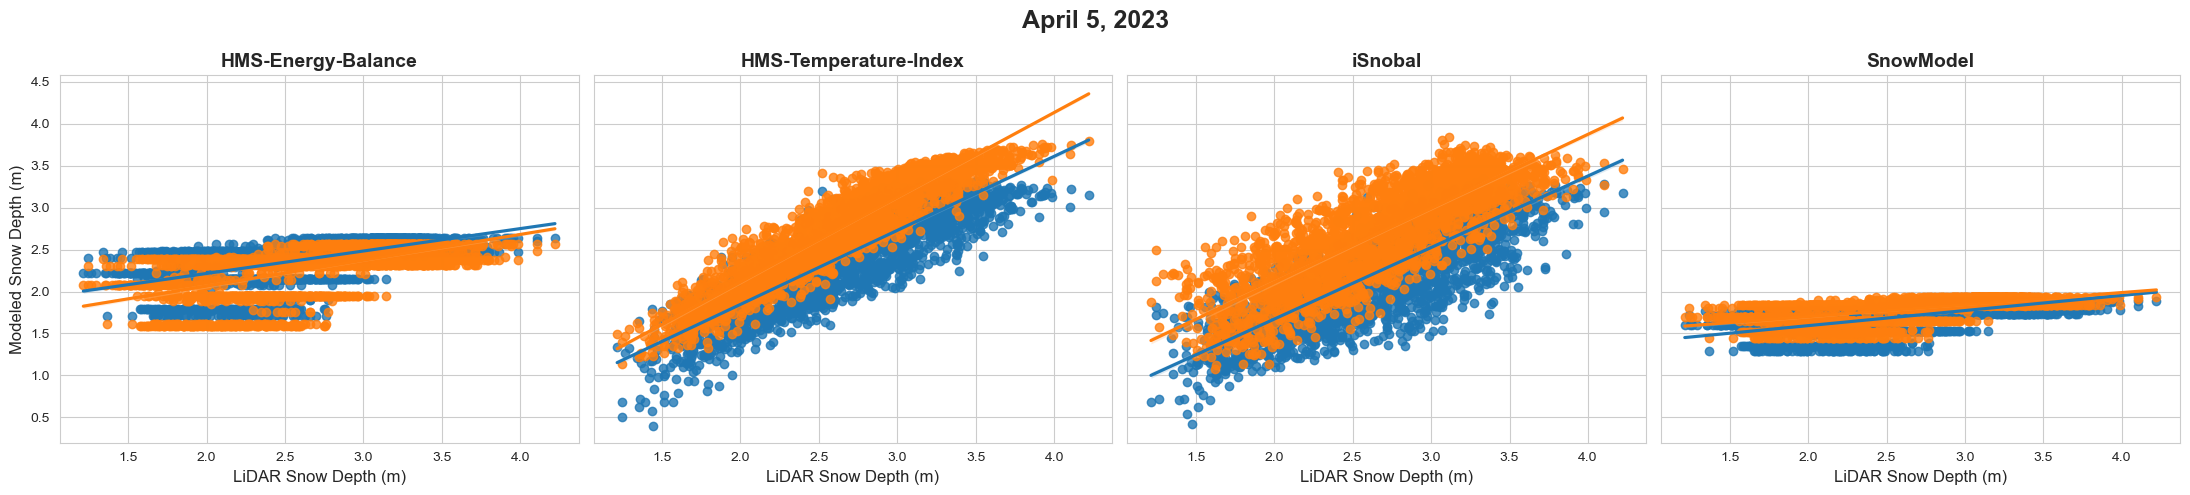

In [198]:
regression_plot_compare('20230405', "April 5, 2023")
# create_regression_plot('20240315', "March 15, 2024")
# create_regression_plot('20240418', "April 18, 2024")
# create_regression_plot('20250404', "April 4, 2025")
# create_regression_plot('20250501', "May 1, 2025")

In [138]:
for model_name, model_data in diff.items():
        raster = rxr.open_rasterio(model_data, masked=True).squeeze()
        print(model_name)        
        min_val = raster.min().item()
        max_val = raster.max().item()
        print(min_val, max_val)



HMS-Energy-Balance
-4.849886894226074 0.4794433116912842
HMS-Temperature-Index
-4.163583278656006 1.158276915550232
iSnobal
-3.483280658721924 0.6743927001953125
SnowModel
-3.6556289196014404 0.5716476440429688


In [77]:
## one pixel with noise in the LiDAR dataset is causing an issues in following cells, so I am going to remove the high noise by filtering lidar diffs for now
## temporary fix, I should potentially return to the lidar
# 
filtered_models = {}
for name, data in diff.items():
    raster = rxr.open_rasterio(data, masked=True).squeeze()
    filtered_data_array = raster.where(raster >= -3.4, drop=False)
    filtered_models[name] = filtered_data_array

print(filtered_models)

{'HMS-Energy-Balance': <xarray.DataArray (y: 84, x: 79)> Size: 27kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
    band         int32 4B 1
  * x            (x) float64 632B 6.016e+05 6.017e+05 ... 6.093e+05 6.094e+05
  * y            (y) float64 672B 4.871e+06 4.871e+06 ... 4.863e+06 4.863e+06
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0, 'HMS-Temperature-Index': <xarray.DataArray (y: 84, x: 79)> Size: 27kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ...,

In [78]:
global_min, global_max = [], []
for data in filtered_models.values():
    global_min.append(data.min().item())
    global_max.append(data.max().item())
    
print(global_min, global_max)

v_abs = [min(global_min), max(global_max)]
v_abs

[-2.3589956760406494, -1.6074657440185547, -1.1461632251739502, -1.636482834815979] [0.44947683811187744, 1.1006909608840942, 0.6743927001953125, 0.5716476440429688]


[-2.3589956760406494, 1.1006909608840942]

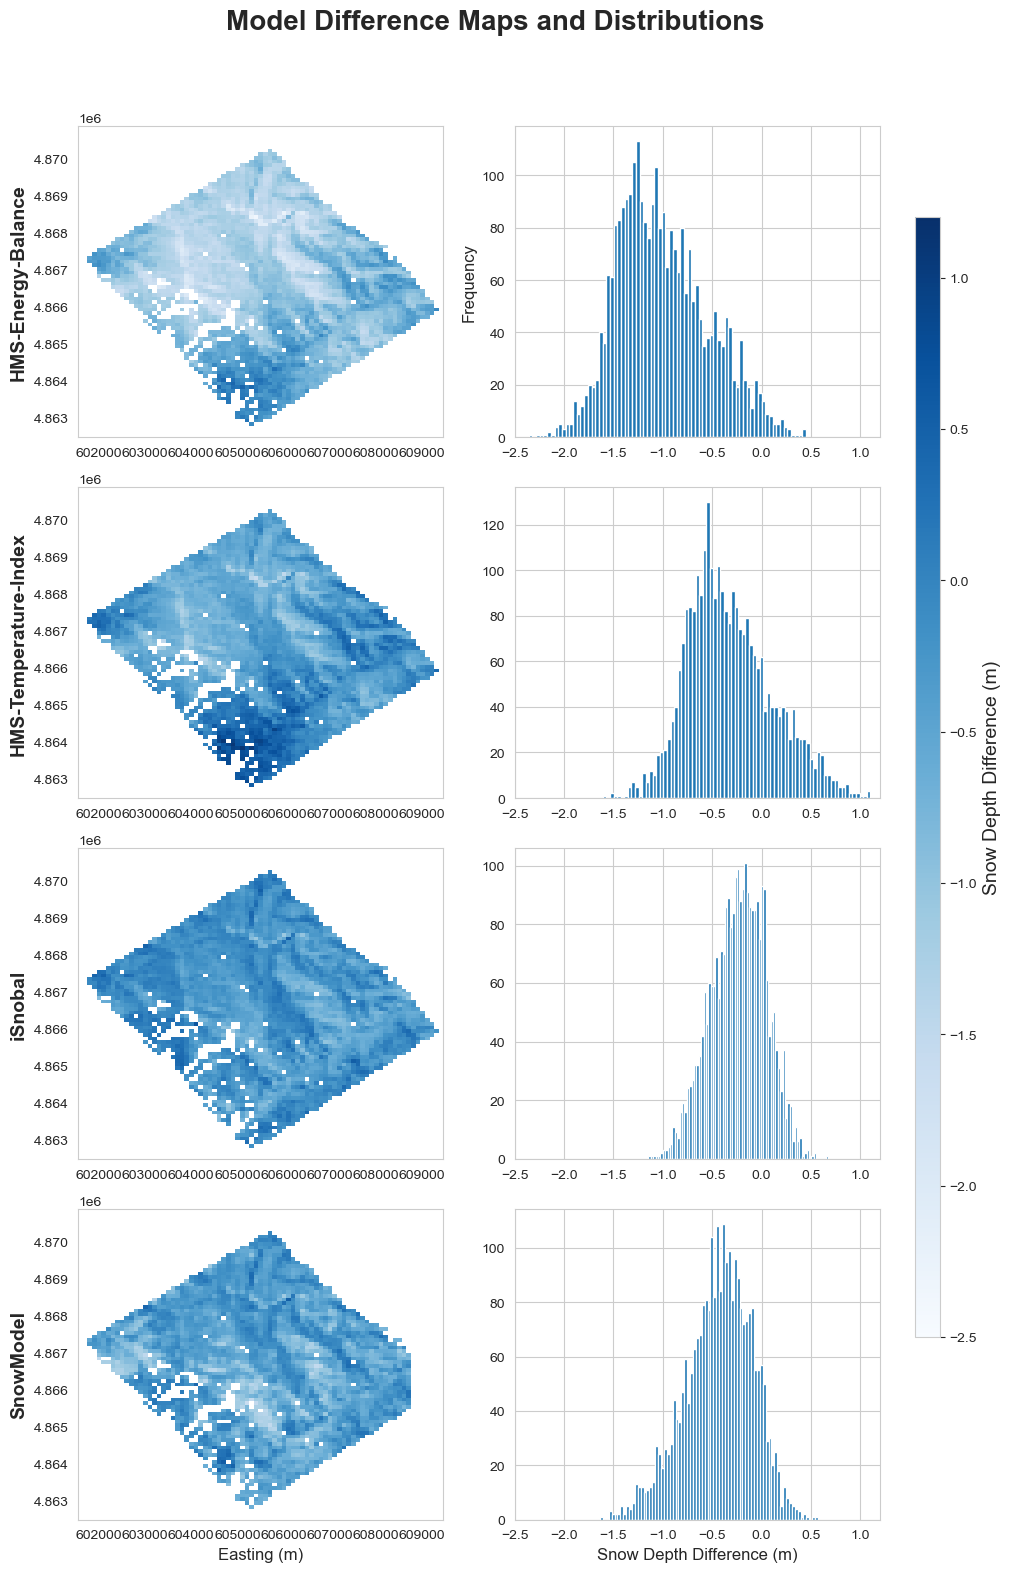

In [80]:
min_fig = -2.5
max_fig = 1.2

fig, axs = plt.subplots(
    nrows=4, 
    ncols=2, 
    figsize=(10, 16), 
    # Link x-axes within columns, making coordinates and hist bins align
    sharex='col' 
)

fig.suptitle('Model Difference Maps and Distributions', fontsize=20, fontweight='bold')

# --- 3. Loop through each model and plot on the correct row ---
for i, (name, data) in enumerate(filtered_models.items()):
    # Define the axes for the current row
    ax_raster = axs[i, 0]
    ax_hist = axs[i, 1]
    
    # --- Plot 1: Raster Map (Left Column) ---
    im = data.plot(ax=ax_raster, cmap='Blues', vmin=min_fig, vmax=max_fig, add_colorbar=False)
    
    # Use the y-label of the raster plot as a row title
    ax_raster.set_title("") 
    ax_raster.set_ylabel(name, fontsize=14, fontweight='bold')
    ax_raster.set_xlabel("")
    #ax_raster.set_xlabel('') # We'll set the x-label only on the last plot

    # --- Plot 2: Histogram (Right Column) ---
    hist_data = data.values.flatten()
    hist_data = hist_data[~np.isnan(hist_data)]
    ax_hist.hist(hist_data, bins=75) #, color='grey' , edgecolor='white')
    ax_hist.set_xlim(min_fig, max_fig) # Apply shared x-axis limits
    
    # Add a vertical line at zero to show the center of the differences
    #ax_hist.axvline(0, color='red', linestyle='--', linewidth=1.5)
    
# --- 4. Finalize titles and labels for columns and axes ---
# Set titles for the two columns on the topmost plots
#axs[0, 0].set_title('Spatial Difference Map', fontsize=16)
#axs[0, 1].set_title('Distribution of Differences', fontsize=16)
for ax in axs.flat:
    ax.tick_params(axis='x', labelbottom=True)
# Set shared axis labels on the bottom-most plots
axs[3, 0].set_xlabel('Easting (m)', fontsize=12)
axs[3, 1].set_xlabel('Snow Depth Difference (m)', fontsize=12)

# Set a y-label for the histograms
axs[0, 1].set_ylabel('Frequency', fontsize=12)


# --- 5. Add a single, shared colorbar ---
fig.tight_layout(rect=[0, 0, 0.9, 0.95]) # Adjust layout to make space

# Add axes for the colorbar [left, bottom, width, height]
cbar_ax = fig.add_axes([0.92, 0.15, 0.025, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Snow Depth Difference (m)', fontsize=14)

plt.show()


NameError: name 'models' is not defined

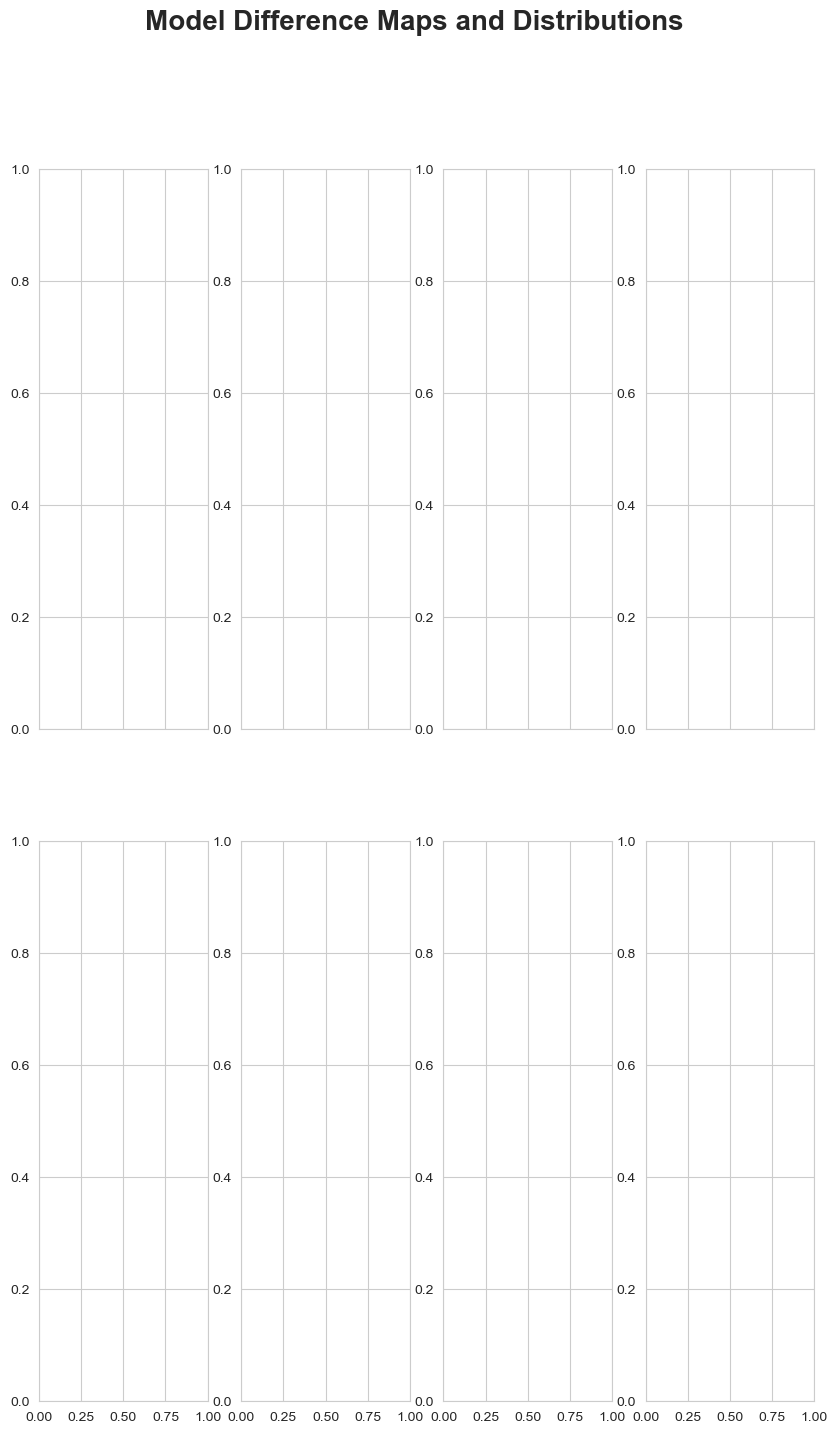

In [1]:
import matplotlib.pyplot as plt
import numpy as np
# 1. IMPORT THE FORMATTER
from matplotlib.ticker import FuncFormatter

# Assuming 'models' and other variables are loaded

min_fig = -1.5
max_fig = 2.5

# 2. DEFINE THE FUNCTION TO FORMAT THE TICK LABELS
# This function will be called for each tick on the x-axis
def kilo_formatter(x, pos):
    """
    Formats the tick value by dividing by 1000 and returning an integer string.
    x: the original tick value (e.g., 602000)
    pos: the position of the tick (we don't need it, but the function requires it)
    """
    return f'{int(x / 1000)}'


fig, axs = plt.subplots(
    nrows=2, 
    ncols=4, 
    figsize=(10, 16), 
    sharex='col'
)

fig.suptitle('Model Difference Maps and Distributions', fontsize=20, fontweight='bold')

# --- Loop through each model and plot ---
for i, (name, data) in enumerate(models.items()):
    ax_raster = axs[i, 0]
    ax_hist = axs[i, 1]
    
    # --- Plot 1: Raster Map ---
    im = data.plot(ax=ax_raster, cmap='Blues', vmin=min_fig, vmax=max_fig, add_colorbar=False)
    
    # 3. APPLY THE CUSTOM FORMATTER TO THE RASTER'S X-AXIS
    ax_raster.xaxis.set_major_formatter(FuncFormatter(kilo_formatter))
    
    ax_raster.set_ylabel(name, fontsize=14, fontweight='bold')

    # --- Plot 2: Histogram ---
    hist_data = data.values.flatten()
    hist_data = hist_data[~np.isnan(hist_data)]
    ax_hist.hist(hist_data, bins=75)
    ax_hist.set_xlim(min_fig, max_fig)
    
# --- Finalize titles and labels ---
axs[0, 0].set_title('Spatial Difference Map', fontsize=16)
axs[0, 1].set_title('Distribution of Differences', fontsize=16)

# Turn on all tick labels
for ax in axs.flat:
    ax.tick_params(axis='x', labelbottom=True)

# 4. UPDATE THE X-AXIS LABEL TO REFLECT THE NEW UNITS
axs[3, 0].set_xlabel('Easting (km)', fontsize=12) # Changed from 'm' to 'km' or (x1000 m)
axs[3, 1].set_xlabel('Snow Depth Difference (m)', fontsize=12)

axs[0, 1].set_ylabel('Frequency', fontsize=12)

# --- Add a single, shared colorbar ---
fig.tight_layout(rect=[0, 0, 0.9, 0.95])
cbar_ax = fig.add_axes([0.92, 0.15, 0.025, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Snow Depth Difference (m)', fontsize=14)

plt.show()
